In [1]:
import pandas as pd
import joblib
import shap
import numpy as np

X_test = pd.read_parquet("../data/processed/X_test.parquet")

risk_model = joblib.load("../model_store/risk_model.pkl")
label_classes = joblib.load("../model_store/risk_label_classes.pkl")


explainer = shap.TreeExplainer(risk_model)

shap_values = explainer.shap_values(X_test.iloc[:200])

print("Classes:", label_classes)


Classes: ['High', 'Low', 'Medium']


In [2]:
print("num features:", X_test.shape[1])
print("X_test columns:", list(X_test.columns))

print("type(shap_values):", type(shap_values))


if isinstance(shap_values, list):
    print("shap_values is a LIST. length (classes):", len(shap_values))
    print("shape of class0:", np.array(shap_values[0]).shape)
else:
    print("shap_values is ARRAY. shape:", np.array(shap_values).shape)


num features: 12
X_test columns: ['deliveries_match', 'deliveries_7d', 'deliveries_28d', 'acwr_std', 'days_since_prev', 'match_day', 'avg_temp_c', 'avg_humidity_pct', 'precip_mm', 'esi_norm', 'age_years', 'inferred_fielding_time_minutes']
type(shap_values): <class 'numpy.ndarray'>
shap_values is ARRAY. shape: (200, 12, 3)


In [3]:

import numpy as np
import pandas as pd


sv = shap_values

print("shap_values shape:", sv.shape)
print("Expected features:", X_test.shape[1])


global_imp = np.mean(np.abs(sv), axis=(0, 2)) 

print("global_imp shape:", global_imp.shape)

imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": global_imp
}).sort_values("mean_abs_shap", ascending=False)

imp_df.head(15)



shap_values shape: (200, 12, 3)
Expected features: 12
global_imp shape: (12,)


,feature,mean_abs_shap
3,acwr_std,2.224117
1,deliveries_7d,0.284366
4,days_since_prev,0.236740
9,esi_norm,0.232448
2,deliveries_28d,0.193610
6,avg_temp_c,0.157733
0,deliveries_match,0.141325
11,inferred_fielding_time_minutes,0.124833
7,avg_humidity_pct,0.116903
8,precip_mm,0.103583


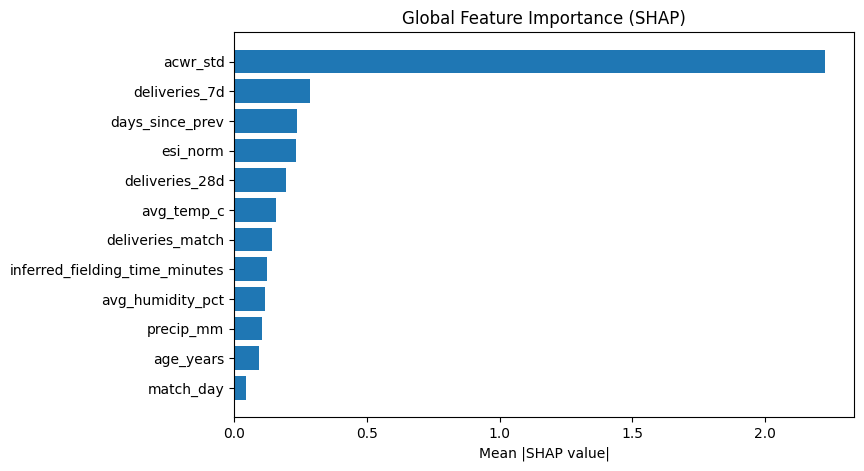

In [4]:
import matplotlib.pyplot as plt

top = imp_df.head(12).iloc[::-1]  
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance (SHAP)")
plt.show()


In [5]:

i = 0  
x_row = X_test.iloc[i:i+1]  

pred_proba = risk_model.predict_proba(x_row)[0]
pred_class = int(np.argmax(pred_proba))

print("Predicted class index:", pred_class)
print("Probabilities:", pred_proba)
print("Predicted label:", label_classes[pred_class])


Predicted class index: 2
Probabilities: [0.05250399 0.09344844 0.85404754]
Predicted label: Medium


In [6]:

contrib = shap_values[i, :, pred_class] 

local_df = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value": contrib,
    "abs_shap": np.abs(contrib),
    "feature_value": x_row.iloc[0].values
}).sort_values("abs_shap", ascending=False)

local_df.head(10)



,feature,shap_value,abs_shap,feature_value
3,acwr_std,0.735705,0.735705,1.391300
9,esi_norm,0.154308,0.154308,0.516900
7,avg_humidity_pct,-0.096398,0.096398,84.361858
4,days_since_prev,0.053298,0.053298,0.000000
1,deliveries_7d,0.043575,0.043575,208.000000
5,match_day,0.043024,0.043024,5.000000
0,deliveries_match,-0.039530,0.039530,23.000000
10,age_years,0.033141,0.033141,25.250000
8,precip_mm,0.027906,0.027906,0.975936
2,deliveries_28d,0.024487,0.024487,598.000000


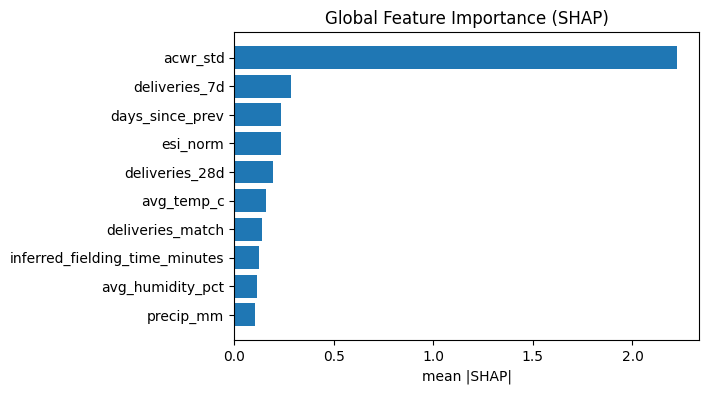

In [7]:

plt.figure(figsize=(6,4))
plt.barh(imp_df["feature"].head(10)[::-1], imp_df["mean_abs_shap"].head(10)[::-1])
plt.title("Global Feature Importance (SHAP)")
plt.xlabel("mean |SHAP|")
plt.show()


Predicted probabilities: {'High': np.float32(0.05250399), 'Low': np.float32(0.09344844), 'Medium': np.float32(0.85404754)}
Predicted label: Medium


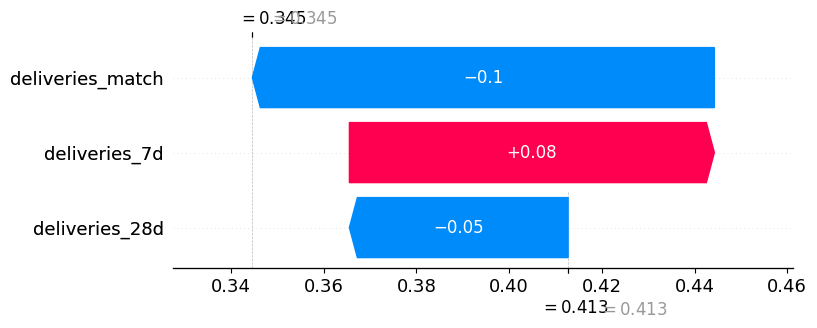

In [8]:

i = 0
x_row = X_test.iloc[i:i+1]

proba = risk_model.predict_proba(x_row)[0]
pred_class = np.argmax(proba)

print("Predicted probabilities:", dict(zip(label_classes, proba)))
print("Predicted label:", label_classes[pred_class])


shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[pred_class],
    shap_values[pred_class][i],
    feature_names=X_test.columns
)
